<a href="https://colab.research.google.com/github/deemaadelgh/lab-4/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [13]:
df = pd.read_csv("SampleSuperstore.csv")

In [14]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [15]:
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [18]:
df.duplicated().sum()

np.int64(17)

In [19]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.isna()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,False,False,False,False,False,False,False,False,False,False,False,False,False
9990,False,False,False,False,False,False,False,False,False,False,False,False,False
9991,False,False,False,False,False,False,False,False,False,False,False,False,False
9992,False,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
df.isna().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [23]:
df_missing = df.copy()

df_missing.loc[0:5, 'Sales'] = np.nan
df_missing.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,6


In [31]:
df_missing['Sales'] = df_missing['Sales'].fillna(df_missing['Sales'].median())

In [27]:
df_missing.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [28]:
df_missing.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,54.816,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,54.816,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,54.816,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,54.816,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,54.816,2,0.20,2.5164


The dataset did not originally have missing values, so I created some in the Sales column for demonstration. I handled them using median imputation because the median is less affected by extreme values and gives a more reliable result.

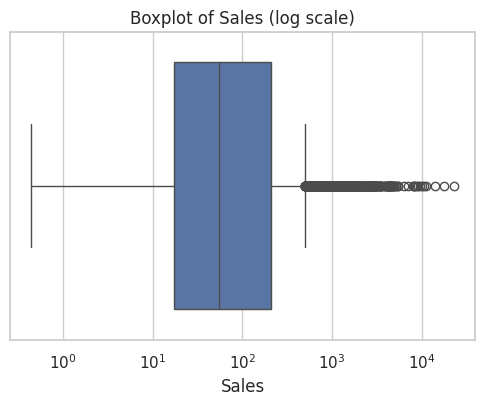

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales'])

plt.xscale('log')
plt.title('Boxplot of Sales (log scale)')
plt.show()

In [36]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]
outliers.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
10,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.1840,9,0.20,85.3092
11,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,911.4240,4,0.20,68.3568


In [38]:
df_no_outliers = df[(df['Sales'] >= lower) & (df['Sales'] <= upper)]

print('df with outliers: ', df.shape)
print('df without outliers: ', df_no_outliers.shape)

df with outliers:  (9977, 13)
df without outliers:  (8810, 13)


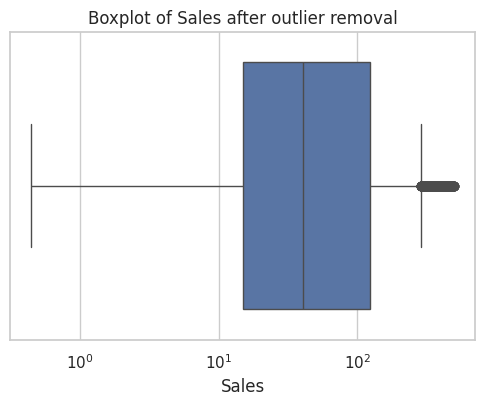

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_no_outliers['Sales'])

plt.xscale('log')
plt.title('Boxplot of Sales after outlier removal')
plt.show()

In [41]:
df_no_outliers

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.960,2,0.0,41.9136
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.620,2,0.0,6.8714
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.368,2,0.2,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.860,7,0.0,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.280,4,0.0,1.9656
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200


In [42]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

In [43]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df_minmax = df_no_outliers.copy()
df_minmax[num_cols] = minmax.fit_transform(df_minmax[num_cols])

df_minmax.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,0.525327,0.076923,0.00,0.860108
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,0.028476,0.076923,0.00,0.835468
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,0.044040,0.076923,0.25,0.832406
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,0.097257,0.461538,0.00,0.840600
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,0.013732,0.230769,0.00,0.832018


In [44]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

df_zscore = df_no_outliers.copy()
df_zscore[num_cols] = standard.fit_transform(df_zscore[num_cols])

df_zscore.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,1.482090,-0.755322,-0.745489,0.625372
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,-0.686637,-0.755322,-0.745489,-0.088197
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,-0.618701,-0.755322,0.199995,-0.176878
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,-0.386414,1.591077,-0.745489,0.060413
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,-0.750996,0.183238,-0.745489,-0.188094


In [45]:
corr = df_no_outliers[['Sales','Quantity','Discount','Profit']].corr()
corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.161697,-0.075704,0.196497
Quantity,0.161697,1.000000,0.017209,0.094291
Discount,-0.075704,0.017209,1.000000,-0.458048
Profit,0.196497,0.094291,-0.458048,1.000000
